In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import os
from pathlib import Path
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

In [2]:
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [3]:
# --------------- Basisverzeichnis (aktuelles Notebook-Verzeichnis) -------------------
base_dir = Path.cwd()

# ------------------ Suche nach dem neusten Preprocessing-Ordner ----------------------
preprocessing_root = base_dir.parent.parent / "3.1_Preprocessing" / "Preprocessing"
timestamp_folders = [f for f in preprocessing_root.iterdir() if f.is_dir()]
if not timestamp_folders:
    raise FileNotFoundError(f"Keine Preprocessing-Ordner in {preprocessing_root} gefunden.")

latest_folder = max(timestamp_folders, key=lambda f: f.stat().st_mtime)
print(f"Verwendeter Preprocessing-Ordner: {latest_folder.name}")

# ---------------------- Zeitstempel finden (neuesten Ordner) -------------------------
try:
    prep_ts = datetime.strptime(latest_folder.name, "%Y-%m-%d_%H-%M-%S")
except ValueError:
    print("Warnung: Preprocessing-Ordnername entspricht nicht dem Schema. Nutze Dateisystem-Zeit.")
    prep_ts = datetime.fromtimestamp(latest_folder.stat().st_mtime)

# ---------------------------- Lade Preprocessed Data ---------------------------------
input_path_prep = latest_folder / "Preprocessed_SOM_Ready.csv"
df_full = pd.read_csv(input_path_prep, low_memory=False)

print(f"Daten erfolgreich aus 3.1_Preprocessing geladen! Shape: {df_full.shape}")

Verwendeter Preprocessing-Ordner: 2026-01-03_17-36-21


Daten erfolgreich aus 3.1_Preprocessing geladen! Shape: (94264, 24)


<div class="alert alert-info">
    <b>Temperature Analysis & Hexagonal SOM</b><br><br>
    <b>Datenquelle:</b><br>
    - Preprocessed Data: Ionen (Log + Gaussian Scaling) + Temperatur (Cleaned)<br>
    <br>
    <b>Filter:</b><br>
    - <b>Nur Temperaturen > 10 °C</b> werden berücksichtigt.
    <br>
    <b>Ziel:</b><br>
    - Clustering mittels SOM (Hexagonal).
    - Analyse der Temperaturverteilung innerhalb der Cluster.
    - Export als PDF Report.
</div>

In [4]:
# --------------------- Features auswählen (erstmal nur Hauptionen) ------------------------
target_ions = ["Na", "Ca", "Mg", "Cl", "HCO3", "SO4"]
features = []
for col in df_full.columns:
    if "_gauss" in col:
        element = col.split("_")[0]
        if element in target_ions:
            features.append(col)

print(f"Input Features für SOM: {features}")

# ----------------------------------------- Filtern -----------------------------------------
df_som = df_full[features + ['temperature_in_c', 'rock_type']].copy()

# ------------------------ Temperatur in numerische Werte umwandeln --------------------------
df_som['temperature_in_c'] = pd.to_numeric(df_som['temperature_in_c'], errors='coerce')

# --------- Nur Temperaturen über 10°C zulassen ODER fehlende Temperaturen (NaN) ------------
len_before_temp = len(df_som)
# Logic: (Temp >= 10) OR (Temp is NaN)
temp_condition = (df_som['temperature_in_c'] >= 10) | (df_som['temperature_in_c'].isna())
df_som = df_som[temp_condition]

print(f"Filter Temp >= 10°C or NaN: {len_before_temp - len(df_som)} Zeilen entfernt. Verbleibend: {len(df_som)}")

initial_len = len(df_som)
df_som.dropna(subset=features, inplace=True)
print(f"Zeilen mit fehlenden Features entfernt: {initial_len - len(df_som)}. Final: {len(df_som)}")

Input Features für SOM: ['Na_in_mmol/L_log_gauss', 'Mg_in_mmol/L_log_gauss', 'Ca_in_mmol/L_log_gauss', 'Cl_in_mmol/L_log_gauss', 'SO4_in_mmol/L_log_gauss', 'HCO3_in_mmol/L_log_gauss']
Filter Temp >= 10°C or NaN: 0 Zeilen entfernt. Verbleibend: 94264
Zeilen mit fehlenden Features entfernt: 19248. Final: 75016


In [5]:
# ------------------------ MinMax Scaling (nur für SOM Training Data) ---------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
data_values = df_som[features].values
data_scaled = scaler.fit_transform(data_values)

print("Daten skaliert.")

Daten skaliert.


In [6]:
# ------------------------------------- SOM Training --------------------------------------------
som_x = 6 
som_y = 6
input_len = len(features)
sigma = 1.5
learning_rate = 0.5

som = MiniSom(x=som_x, y=som_y, input_len=input_len, 
              sigma=sigma, learning_rate=learning_rate, 
              topology='hexagonal', neighborhood_function='gaussian', 
              activation_distance='euclidean', random_seed=42)

som.random_weights_init(data_scaled)

print(f"Starte SOM Training ({som_x}x{som_y} Hexagonal)...")
som.train_random(data_scaled, 10000) 
print("Training beendet.")

Starte SOM Training (6x6 Hexagonal)...


Training beendet.


In [7]:
# ----------------------- Temperatur Analyse Vorbereitung ---------------------------
winner_coords = []
for x in data_scaled:
    w = som.winner(x)
    winner_coords.append(w)

df_som['som_x'] = [c[0] for c in winner_coords]
df_som['som_y'] = [c[1] for c in winner_coords]

# ----------------------- Mean Temperature Map berechnen -----------------------------
temp_map = np.full((som_x, som_y), np.nan)

agg = df_som.groupby(['som_x', 'som_y'])['temperature_in_c'].mean()

for (gx, gy), val in agg.items():
    temp_map[gx, gy] = val

print("Mean Temperature Map berechnet.")

Mean Temperature Map berechnet.


In [8]:
# ---------------------------- Plot Funktion für PDF --------------------------------
def plot_hex_map_to_axis(ax, data_matrix, title, cmap='viridis', label_suffix='', annotate=False):
    sy, sx = data_matrix.shape
    ax.set_aspect('equal')
    patches = []
    colors = []
    
    for y in range(sy):
        for x in range(sx):
            val = data_matrix[y, x]
            if np.isnan(val): 
                continue 
                
            offset = 0.5 if y % 2 != 0 else 0.0
            center_x = x + offset
            center_y = y * (np.sqrt(3) / 2)
            radius = 1 / np.sqrt(3)
            
            hex_poly = mpatches.RegularPolygon(
                (center_x, center_y), numVertices=6, radius=radius, 
                orientation=np.radians(30), edgecolor='k', linewidth=0.5
            )
            patches.append(hex_poly)
            colors.append(val)
            
            if annotate:
                ax.text(center_x, center_y, f"{val:.1f}", ha='center', va='center', 
                        fontsize=7, color='black', fontweight='bold')
            
    if not patches:
        return

    collection = PatchCollection(patches, cmap=cmap, alpha=0.9)
    collection.set_array(np.array(colors))
    ax.add_collection(collection)
    
    ax.set_xlim(-0.5, sx + 0.5)
    ax.set_ylim(-0.5, sy * (np.sqrt(3)/2) + 0.5)
    ax.axis('off')
    ax.set_title(title, fontsize=12)
    return collection

In [9]:
# ------------------------ PDF Report Erstellung ------------------------
output_root = base_dir / "MiniSom_Results"
output_root.mkdir(exist_ok=True)

# ------------------------- Create Run Folder ---------------------------
current_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_folder = output_root / f"Run_{current_ts}"
run_folder.mkdir(parents=True, exist_ok=True)
print(f"Output Folder: {run_folder}")


pdf_path = run_folder / "SOM_Report_Temperature.pdf"
print(f"Erstelle Report: {pdf_path} ...")

# --------------------------- Calculate Count ----------------------------
temp_count = df_som['temperature_in_c'].count()
with PdfPages(pdf_path) as pdf:
    
    # -------------------------------- Deckblatt ----------------------------
    plt.figure(figsize=(8, 6))
    plt.text(0.5, 0.5, f"SOM Temperature Analysis Report\n\nHexagonal Self-Organizing Map (10x10)\nInput: Major Ions (Log+Gauss)\nOverlay: Temperature (Mean & Dist)\nFILTER: Only Temp > 10\u00b0C\n\nTotal Data Points: {temp_count}", 
             ha='center', va='center', fontsize=20)
    plt.axis('off')
    pdf.savefig()
    plt.close()
    
    # ------------------------------ Abstandsmatrix ---------------------------
    fig, ax = plt.subplots(figsize=(8, 8))
    u_matrix = som.distance_map()
    col_u = plot_hex_map_to_axis(ax, u_matrix, "U-Matrix (Distance Map)", cmap='bone_r')
    plt.colorbar(col_u, ax=ax, fraction=0.046, pad=0.04, label='Distance')
    pdf.savefig(fig)
    plt.close(fig)
    
    # ------------------------- Durchschnittstemperatur --------------------------
    fig, ax = plt.subplots(figsize=(10, 10))
    col_t = plot_hex_map_to_axis(ax, temp_map, "Mean Temperature per Cluster (> 10°C)", cmap='coolwarm', annotate=True)
    plt.colorbar(col_t, ax=ax, fraction=0.046, pad=0.04, label='Temp °C')
    pdf.savefig(fig)
    plt.close(fig)
    
    # ---------------------------- Component Plane -------------------------------
    W = som.get_weights()
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    for i, feature in enumerate(features):
        short = feature.split("_")[0]
        col_c = plot_hex_map_to_axis(axes[i], W[:,:,i], f"{short}", cmap='viridis')
    plt.suptitle("Component Planes (Ion Distribution)")
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close(fig)
    
    # ---------------------- Detaillierte Beschreibung -----------------------------
    cluster_counts = df_som.groupby(['som_x', 'som_y']).size().sort_values(ascending=False)
    all_clusters = cluster_counts.index.tolist()
    
    plots_per_page = 9
    chunks = [all_clusters[i:i + plots_per_page] for i in range(0, len(all_clusters), plots_per_page)]
    
    print(f"Erstelle Verteilungs-Plots für {len(all_clusters)} Cluster auf {len(chunks)} Seiten...")
    
    for page_idx, chunk in enumerate(chunks):
        fig, axes = plt.subplots(3, 3, figsize=(12, 12))
        axes = axes.flatten()
        plt.suptitle(f"Temp Distribution (>10°C) - Page {page_idx + 1}/{len(chunks)} (Sorted by Size)", fontsize=16)
        
        for i, (cx, cy) in enumerate(chunk):
            subset = df_som[(df_som['som_x'] == cx) & (df_som['som_y'] == cy)]
            temps = subset['temperature_in_c'].dropna()
            
            ax = axes[i]
            if len(temps) == 0:
                ax.text(0.5, 0.5, "No Data", ha='center')
            else:
                sns.histplot(temps, kde=True, ax=ax, color='crimson', kde_kws={'cut': 0})
            
            count = len(temps)
            ax.set_title(f"Cluster ({cx}, {cy}) - N={count}")
            ax.set_xlabel("Temp °C")

        for j in range(len(chunk), plots_per_page):
            axes[j].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
        pdf.savefig(fig)
        plt.close(fig)

print("Report fertiggestellt.")

Output Folder: C:\Users\lucca\OneDrive\SPEICHER\Hochschule\7. Semester\Abschlussarbeit Bearbeitung\Jupyter Notebooks\3.2_Machine-Learning\MiniSom\MiniSom_Results\Run_2026-01-03_17-36-59
Erstelle Report: C:\Users\lucca\OneDrive\SPEICHER\Hochschule\7. Semester\Abschlussarbeit Bearbeitung\Jupyter Notebooks\3.2_Machine-Learning\MiniSom\MiniSom_Results\Run_2026-01-03_17-36-59\SOM_Report_Temperature.pdf ...


Erstelle Verteilungs-Plots für 36 Cluster auf 4 Seiten...


Report fertiggestellt.


Erstelle Rock Type Report: C:\Users\lucca\OneDrive\SPEICHER\Hochschule\7. Semester\Abschlussarbeit Bearbeitung\Jupyter Notebooks\3.2_Machine-Learning\MiniSom\MiniSom_Results\Run_2026-01-03_17-36-59\SOM_Report_RockType.pdf...


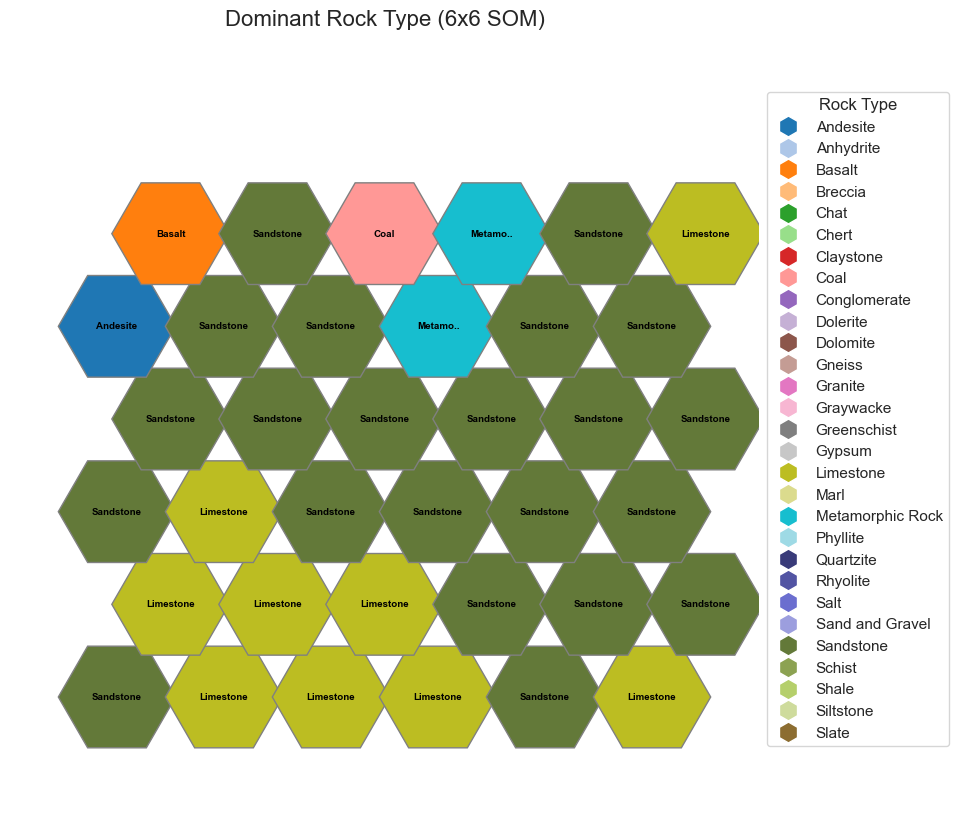

Erstelle Rock Type Histogramme per Cluster...


C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucc

C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucc

C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')


C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucc

C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')


C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucc

C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
C:\Users\lucca\AppData\Local\Temp\ipykernel_20128\2018893504.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')


Fertig! Rock PDF gespeichert: C:\Users\lucca\OneDrive\SPEICHER\Hochschule\7. Semester\Abschlussarbeit Bearbeitung\Jupyter Notebooks\3.2_Machine-Learning\MiniSom\MiniSom_Results\Run_2026-01-03_17-36-59\SOM_Report_RockType.pdf


In [10]:

# ----------------------- Rock Type Visualisierung & PDF Export ---------------------
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.colors as mcolors
from matplotlib.patches import RegularPolygon
from datetime import datetime

# -------------------------------- Aktuellen Ordner ---------------------------------
if 'run_folder' not in locals():
    output_root = base_dir / "MiniSom_Results"
    current_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    run_folder = output_root / f"Run_{current_ts}"
    run_folder.mkdir(parents=True, exist_ok=True)

rock_pdf_path = run_folder / "SOM_Report_RockType.pdf"

print(f"Erstelle Rock Type Report: {rock_pdf_path}...")

# --------------------- 1. Gesteinstypen mappen -----------------------------------
node_rock_types = {}
for i, x in enumerate(data_scaled):
    w = som.winner(x)
    if 'rock_type' in df_som.columns:
        r_type = df_som.iloc[i]['rock_type']
    else:
        continue 
        
    # ------------------------------ Normalisieren -----------------------------
    if pd.isna(r_type):
        continue
        
    r_str = str(r_type).strip()
    if r_str == "": continue
    if r_str.lower() == "unknown": continue
    if r_str.lower() == "nan": continue
    
    if w not in node_rock_types:
        node_rock_types[w] = []
    node_rock_types[w].append(r_str)

# ----------------------------------- 2. Kontext -----------------------------
with PdfPages(rock_pdf_path) as pdf:
    # Deckseite
    total_rocks_mapped = sum(len(v) for v in node_rock_types.values())
    
    plt.figure(figsize=(8, 6))
    plt.text(0.5, 0.5, f"SOM Rock Type Analysis Report\n\nHexagonal Self-Organizing Map (10x10)\nFiltered Validation Data\n\nTotal Data Points Included: {total_rocks_mapped}", 
             ha='center', va='center', fontsize=20)
    plt.axis('off')
    pdf.savefig()
    plt.close()
    
    # ------------------------------- Map Plotten ---------------------------------
    f, ax = plt.subplots(figsize=(12, 10))
    ax.set_aspect('equal')

    # ---------------------------- Farben und Gesteine ----------------------------
    all_rocks = []
    for k, v in node_rock_types.items():
        all_rocks.extend(v)
    unique_rocks = sorted(list(set(all_rocks)))
    if 'Unknown' in unique_rocks: 
        unique_rocks.remove('Unknown')
        unique_rocks.append('Unknown')

    # -------------------------------- Farbmap exportieren --------------------------
    cmap_objs = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
    rock_color_map = {}
    for i, r in enumerate(unique_rocks):
        rock_color_map[r] = cmap_objs[i % len(cmap_objs)]
    
    rock_color_map['Unknown'] = (0.9, 0.9, 0.9, 1)
    rock_color_map['Empty'] = (1, 1, 1, 0)

    # --------------------------- Hexagone darstellen --------------------------------
    for i in range(som_x):
        for j in range(som_y):
            if (i, j) in node_rock_types:
                rocks = node_rock_types[(i, j)]
                if rocks:
                    dom_rock = max(set(rocks), key=rocks.count)
                else:
                    dom_rock = 'Empty'
            else:
                dom_rock = 'Empty'
            
            color = rock_color_map.get(dom_rock, (0.8, 0.8, 0.8, 1))
            
            wy = i * np.sqrt(3) / 2
            wx = j + 0.5 * (i % 2)
            
            hex = RegularPolygon((wx, wy), numVertices=6, radius=0.95/np.sqrt(3), 
                                 orientation=np.pi/2, 
                                 facecolor=color, alpha=1, edgecolor='gray')
            ax.add_patch(hex)
            
            if dom_rock != 'Empty':
                label = dom_rock
                if len(label) > 10: label = label[:6] + ".."
                plt.text(wx, wy, label, ha='center', va='center', fontsize=7, color='black', weight='bold')

    ax.set_xlim(-1, som_y)
    ax.set_ylim(-1, som_x * np.sqrt(3)/2 + 1)
    plt.axis('off')
    
    legend_elements = [plt.Line2D([0], [0], marker='h', color='w', label=r, 
                          markerfacecolor=c, markersize=15) for r, c in rock_color_map.items() if r != 'Empty' and r in unique_rocks]
    
    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Rock Type")
    plt.title(f"Dominant Rock Type ({som_x}x{som_y} SOM)", fontsize=16)
    
    pdf.savefig(f, bbox_inches='tight')
    plt.show()
    plt.close(f)
    
    # --------------------------- Histogramme je Cluster ---------------------------------
    print("Erstelle Rock Type Histogramme per Cluster...")
    cluster_counts = df_som.groupby(['som_x', 'som_y']).size().sort_values(ascending=False)
    all_clusters = cluster_counts.index.tolist()
    
    plots_per_page = 9
    chunks = [all_clusters[i:i + plots_per_page] for i in range(0, len(all_clusters), plots_per_page)]
    
    for page_idx, chunk in enumerate(chunks):
        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        axes = axes.flatten()
        plt.suptitle(f"Rock Type Dist - Page {page_idx + 1}/{len(chunks)} (Sorted by Size)", fontsize=16)
        
        for i, (cx, cy) in enumerate(chunk):
            ax = axes[i]
            if (cx, cy) in node_rock_types:
                rocks = node_rock_types[(cx, cy)]
                if rocks:
                    # ---------------------------- Gestein zählen ----------------------
                    r_counts = pd.Series(rocks).value_counts().head(5) # Top 5
                    sns.barplot(x=r_counts.values, y=r_counts.index, ax=ax, palette='viridis')
                    ax.set_title(f"Cluster ({cx}, {cy}) - N={len(rocks)}")
                    ax.set_xlabel("Count")
                else:
                    ax.text(0.5, 0.5, "No Data", ha='center')
            else:
                ax.text(0.5, 0.5, "No Data", ha='center')
        
        # ------------------- Leere Plots ----------------------
        for j in range(len(chunk), plots_per_page):
            axes[j].axis('off')
            
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        pdf.savefig(fig)
        plt.close(fig)

print(f"Fertig! Rock PDF gespeichert: {rock_pdf_path}")
